In [1]:
# LSTM
# 256 hidden units
# 5 Gaussian mixtures
# diagonal covariance matrices (no cross-correlation / factored Gaussians)
# In training, store mu/sigma from the VAE encoder for each frame and sample z from scratch
# tanh to clip outputs into [-1, +1]
# LSTM - gradient clipping

In [2]:
import einops
import h5py
import jax.numpy as jnp
import optax
from flax import nnx
from jax import Array
from tqdm import trange

from wm.rnn import MDNRNN

In [3]:
vae_name = "sigma1_vae2"
with h5py.File("../data/world_models.h5", libver="latest") as f:
    mu_file = f[f"latents/{vae_name}/mu"][...]
    logvar_file = f[f"latents/{vae_name}/logvar"][...]

    actions_file = f["actions"][...]
    episodes_dset = f["episodes"]
    starts_file = episodes_dset["start"][...]
    ends_file = episodes_dset["end"][...]

In [4]:
print(f"     mu: {mu_file.nbytes / 1024**3:.2f} GB")
print(f" logvar: {logvar_file.nbytes / 1024**3:.2f} GB")
print(f"actions: {actions_file.nbytes / 1024**3:.2f} GB")
print(f" starts: {starts_file.nbytes / 1024**1:.1f} kB")
print(f"   ends: {ends_file.nbytes / 1024**1:.1f} kB")

     mu: 1.20 GB
 logvar: 1.20 GB
actions: 0.11 GB
 starts: 79.1 kB
   ends: 79.1 kB


In [5]:
import numpy as np

# some of the episodes are truncated for some reason - ignore them
ep_maxlen = 1000
valid_episodes = np.flatnonzero((ends_file - starts_file) == ep_maxlen)

# this is a pain, but our data contains some episodes which are truncated halfway - unsure why
# Let's clean it up
n_episodes = len(valid_episodes)
mu = np.zeros(shape=(n_episodes, ep_maxlen, 32), dtype=np.float32)
logvar = np.zeros(shape=(n_episodes, ep_maxlen, 32), dtype=np.float32)
actions = np.zeros(shape=(n_episodes, ep_maxlen, 3), dtype=np.float32)

for i, valid_ep_ix in enumerate(valid_episodes):
    st = starts_file[valid_ep_ix]
    end = st + ep_maxlen
    mu[i, :, :] = mu_file[st:end, :].reshape(1, ep_maxlen, -1)
    logvar[i, :, :] = logvar_file[st:end, :].reshape(1, ep_maxlen, -1)
    actions[i, :, :] = actions_file[st:end, :].reshape(1, ep_maxlen, -1)

In [6]:
def sample_batch(rng, batch_size):
    batch_ix = rng.choice(n_episodes, size=batch_size)

    mu_batch = jnp.array(mu[batch_ix])
    logvar_batch = jnp.array(logvar[batch_ix])
    actions_batch = jnp.array(actions[batch_ix])
    return mu_batch, logvar_batch, actions_batch

In [7]:
def sample_latent(rng, logvar_b, mu_b):
    sigma = jnp.exp(0.5 * logvar_b)  # ensure the standard deviation is positive

    # construct the latent vector as z = mu + sigma * N(0, 1)
    eps = rng.normal(mu_b.shape, dtype=mu_b.dtype)
    return mu_b + sigma * eps


@nnx.value_and_grad
def loss_fn(model, x):
    logprobs = model.logprobs(x)
    return -logprobs.mean()


@nnx.jit
def train_step(
    model: MDNRNN,
    optim: nnx.Optimizer,
    batch: tuple[Array, ...],
    latent_rng: nnx.Rngs,
):
    mu_b, logvar_b, actions_b = batch
    z = sample_latent(latent_rng, logvar_b, mu_b)
    concat, _ = einops.pack([z, actions_b], "B T *")
    loss, grads = loss_fn(model, concat)

    # apply gradient clipping
    optim.update(model, grads)
    return loss

In [8]:
rnn = MDNRNN(32, 3, rngs=nnx.Rngs(0))

In [9]:
train_steps = 4000
peak_lr = 2e-3
lr_decay_steps = 4000
batch_size = 32

lr_schedule = optax.cosine_decay_schedule(peak_lr, lr_decay_steps, alpha=1e-2)
tx = optax.chain(
    optax.clip(1.0),
    optax.adamw(learning_rate=lr_schedule),
)

optim = nnx.Optimizer(rnn, tx, wrt=nnx.Param)

sample_rng = np.random.default_rng(0)
latent_rng = nnx.Rngs(0)
batch = sample_batch(sample_rng, batch_size=1)

losses = []
for i in (pbar := trange(train_steps)):
    batch = sample_batch(sample_rng, batch_size)
    loss = train_step(rnn, optim, batch, latent_rng)
    losses.append(loss)

    pbar.set_description_str(f"{loss:.2f}")

41.23: 100%|██████████| 4000/4000 [27:22<00:00,  2.44it/s]


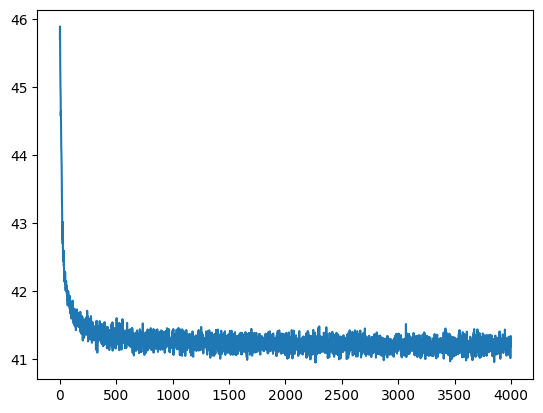

In [10]:
import matplotlib.pyplot as plt

plt.plot(losses)

In [ ]:
from wm.utils import save_model

save_model(rnn, "../experiments/rnn/sigma1_vae2")

Saved model to /Users/alexinch/noodling/world_models_paper/checkpoints/../experiments/rnn/sigma1_vae2


In [13]:
rnn

MDNRNN( # Param: 382,533 (1.5 MB), RngState: 4 (24 B), Total: 382,537 (1.5 MB)
  action_dim=3,
  latent_dim=32,
  linear=Linear( # Param: 83,525 (334.1 KB)
    bias=Param( # 325 (1.3 KB)
      value=Array(shape=(325,), dtype=dtype('float32'))
    ),
    dot_general=<function dot_general at 0x115ccc7c0>,
    dtype=None,
    in_features=256,
    kernel=Param( # 83,200 (332.8 KB)
      value=Array(shape=(256, 325), dtype=dtype('float32'))
    ),
    out_features=325,
    param_dtype=float32,
    precision=None,
    preferred_element_type=None,
    promote_dtype=<function promote_dtype at 0x116d7ae80>,
    use_bias=True
  ),
  n_mixtures=5,
  rngs=Rngs( # RngState: 2 (12 B)
    default=RngStream( # RngState: 2 (12 B)
      count=RngCount( # 1 (4 B)
        value=Array(5, dtype=uint32),
        tag='default'
      ),
      key=RngKey( # 1 (8 B)
        value=Array((), dtype=key<fry>) overlaying:
        [0 0],
        tag='default'
      ),
      tag='default'
    )
  ),
  rnn=RNN( # Param: